In [1]:
import pandas as pd
import numpy as np
import socket
from DATA.stock_invest_function import *

In [2]:

# DB 접속 정보 설정
db_info = {
    'user': 'stox7412',         # 예: 'root'
    'password': 'Apt106503!~', # 예: '1234'
    'host': get_db_host(),
    # 'host': 'hystox74.synology.me',         # 예: 'localhost' 또는 IP
    'port': '3307',              # 기본 포트는 보통 3306
    'database': 'investar'        # 예: 'trade_data'
}

trade_df = fetch_table_data(db_info, "us_trade_quarter_data_with_forecast")

# date를 datetime으로 변환
trade_df['date'] = pd.to_datetime(trade_df['date'])

# pivot table 생성
trade_pivot_df = trade_df.pivot_table(index='date', columns='hs_code_6d', values='expDlr')

# YoY 성장률 계산 (4분기 전 대비), 경고 방지
yoy_trade_growth = trade_pivot_df.pct_change(periods=4, fill_method=None) * 100

✅ 'us_trade_quarter_data_with_forecast' 테이블에서 24759건의 데이터를 가져왔습니다.


In [3]:
fs_df = fetch_table_data(db_info, "US_fundq")

# 0. 사전 준비
df = fs_df.copy()

# 1. 날짜 컬럼 정제
df['date'] = pd.to_datetime(df['date'])

# 2. 분기 종료일 기준으로 집계
df['quarter'] = df['date'].dt.to_period('Q').dt.to_timestamp(how='end')

# 3. 원하는 재무 변수만 선택
target_vars = ['saleq']
id_var = 'tic'  # 고유 기업 식별자
value_vars = [col for col in df.columns if col in target_vars]

# 4. 필요한 열만 추출하고 결측 제외
df_filtered = df[['quarter', id_var] + value_vars].dropna(subset=value_vars, how='all')

# 5. 긴 형태로 변환
df_long = df_filtered.melt(
    id_vars=['quarter', id_var],
    value_vars=value_vars,
    var_name='metric',
    value_name='value'
)

# 6. 피벗: (행: quarter, 열: (tic, metric), 값: value)
pivot_df = df_long.pivot_table(index='quarter', columns=[id_var, 'metric'], values='value')

# 7. 전년 동분기 대비 증가율 계산
yoy_growth = pivot_df.pct_change(periods=4, fill_method=None) * 100

# 8. index를 YYYY-MM-DD 문자열로 변경
yoy_growth.index = yoy_growth.index.strftime('%Y-%m-%d')

# 9. 컬럼명이 MultiIndex일 경우, 'tic'만 남기기
if isinstance(yoy_growth.columns, pd.MultiIndex):
    yoy_growth.columns = yoy_growth.columns.get_level_values(0)

# 결과
yoy_sales_growth = yoy_growth

✅ 'US_fundq' 테이블에서 1334117건의 데이터를 가져왔습니다.


In [5]:
def compute_cross_correlation(yoy_trade_growth, yoy_sales_growth, start_date, end_date):
    # 1. 날짜 인덱스를 datetime 형식으로 통일
    yoy_trade_growth.index = pd.to_datetime(yoy_trade_growth.index)
    yoy_sales_growth.index = pd.to_datetime(yoy_sales_growth.index)

    # 2. 날짜 범위 필터링
    trade_filtered = yoy_trade_growth.loc[start_date:end_date]
    sales_filtered = yoy_sales_growth.loc[start_date:end_date]

    # 3. 공통 인덱스만 사용
    common_index = trade_filtered.index.intersection(sales_filtered.index)
    trade_filtered = trade_filtered.loc[common_index]
    sales_filtered = sales_filtered.loc[common_index]

    # 4. 결측치 제거: 동일한 인덱스를 갖는 두 데이터프레임에 대해,
    #    각 조합마다 NaN 이 없는 시점만 추출
    # 교차 상관계수 계산을 위한 빈 결과 df 생성
    result = pd.DataFrame(index=trade_filtered.columns, columns=sales_filtered.columns, dtype=float)

    # 5. HS코드(h)와 Ticker(t)별로 상관계수 계산
    for h in trade_filtered.columns:
        for t in sales_filtered.columns:
            merged = pd.concat([trade_filtered[h], sales_filtered[t]], axis=1).dropna()
            if len(merged) > 1:  # 상관계수 계산을 위해 최소 2개 이상 필요
                result.at[h, t] = merged.corr().iloc[0, 1]

    return result

# 사용 예시
start_date = '2020-01-01'
end_date = '2024-12-31'

# correlation_result = compute_cross_correlation(yoy_trade_growth, yoy_sales_growth, start_date, end_date)

In [7]:
path = r"corelation_result_US.xlsx"

correlation_result = pd.read_excel(path)

correlation_result = correlation_result.set_index('tic')

In [8]:
def top_hscodes_for_ticker(df: pd.DataFrame, ticker: str, n: int = 5, use_abs: bool = False) -> pd.DataFrame:
    """
    ticker(행)을 기준으로 상관계수가 높은 HS code n개를 반환.
    Parameters
    ----------
    df : DataFrame  # index=ticker, columns=hs_code, values=corr
    ticker : str
    n : int         # 상위 개수
    use_abs : bool  # True면 절댓값 기준(강한 양/음 모두), False면 양의 방향만 큰 값 기준

    Returns
    -------
    DataFrame[["hs_code","corr"]]  # corr는 원래 부호 유지
    """
    if ticker not in df.index:
        raise ValueError(f"ticker '{ticker}' 가 index에 없습니다.")

    s = df.loc[ticker].dropna()

    if s.empty:
        return pd.DataFrame(columns=["hs_code","corr"])

    if use_abs:
        order = s.abs().sort_values(ascending=False).index
    else:
        order = s.sort_values(ascending=False).index  # 양의 상관 높은 순

    top = s.loc[order].head(n)
    return top.rename_axis("hs_code").reset_index(name="corr")


def top_tickers_for_hscode(df: pd.DataFrame, hs_code: str, n: int = 5, use_abs: bool = False) -> pd.DataFrame:
    """
    HS code(열)를 기준으로 상관계수가 높은 ticker n개를 반환.
    Parameters는 위 함수와 동일.
    """
    if hs_code not in df.columns:
        raise ValueError(f"hs_code '{hs_code}' 가 columns에 없습니다.")

    s = df[hs_code].dropna()

    if s.empty:
        return pd.DataFrame(columns=["tic","corr"])

    if use_abs:
        order = s.abs().sort_values(ascending=False).index
    else:
        order = s.sort_values(ascending=False).index  # 양의 상관 높은 순

    top = s.loc[order].head(n)
    return top.rename_axis("tic").reset_index(name="corr")


In [13]:
# HS '851762'와 상관 높은 ticker 8개 (양의 상관 기준)
top_tickers_for_hscode(correlation_result, "841590", n=20)

# HS '851762'와 절댓값 기준으로 가장 강한 ticker 8개
# top_tickers_for_hscode(df, "851762", n=20, use_abs=True)


,tic,corr
0,AMPE,0.967725
1,GSIH,0.967725
2,BCAL,0.912133
3,YOSH,0.890741
4,MBC,0.828523
5,UPB,0.821659
6,GENK,0.806316
7,AKUMQ,0.785735
8,ASNS,0.782609
9,DIBS,0.754507


In [18]:
# ticker 'AAPL'과 가장 높은 HS code 10개 (양의 상관 기준)
top_hscodes_for_ticker(correlation_result, "CCK", n=20)

,hs_code,corr
0,480990,0.745187
1,280700,0.742361
2,851713,0.737890
3,761090,0.727698
4,271019,0.725091
5,290243,0.704846
6,730799,0.704575
7,390761,0.704155
8,731210,0.692740
9,540211,0.664457


In [16]:
correlation_result.loc['CARR'][['841590']]

841590    0.407348
Name: CARR, dtype: float64

In [ ]:
# ticker 'AAPL'과 가장 높은 HS code 10개 (양의 상관 기준)
top_hscodes_for_ticker(df, "AAPL", n=10)

# ticker 'AAPL'과 절댓값 기준으로 가장 강한 HS code 10개 (음/양 모두 포함)
top_hscodes_for_ticker(df, "AAPL", n=10, use_abs=True)

In [43]:
correlation_result

,tic,121120,121221,151550,151590,170199,190230,190590,200599,200830,...,903149,903180,903190,903289,940130,940199,940330,940540,950300,970191
0,3BCTI,-0.251321,0.141204,0.109421,0.080630,-0.078089,0.143128,-0.374858,-0.120553,-0.013924,...,0.129800,-0.158789,0.015391,-0.010798,0.018151,NaN,0.015181,-0.276965,-0.418743,NaN
1,3BHMSQ,-0.206359,-0.362598,0.487431,-0.086689,0.292915,0.248221,0.479479,0.569484,0.499049,...,-0.145530,-0.373222,-0.211029,-0.116294,-0.006930,NaN,-0.257990,0.071389,-0.485276,NaN
2,3CAPS.,0.099252,0.180580,0.109146,-0.016711,0.385151,0.343397,0.096067,-0.147662,0.124999,...,0.242057,0.073371,-0.054139,0.077847,-0.146359,NaN,-0.252644,-0.164587,-0.154958,NaN
3,3CHLD,0.099713,-0.313665,0.072016,0.132118,-0.332264,-0.487151,0.217725,0.024049,0.186615,...,-0.063226,-0.273205,-0.199028,-0.510954,-0.029960,NaN,0.128541,-0.005832,0.033478,NaN
4,3DAYR,-0.232243,-0.353590,0.318771,-0.072466,0.174651,0.199721,0.511650,0.758684,0.524287,...,-0.134894,-0.197151,-0.187578,-0.084656,-0.122235,NaN,-0.203486,0.112775,-0.307771,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4764,ZVRA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.021509,NaN,NaN,NaN,-0.409792
4765,ZWS,0.095688,0.028489,-0.198340,-0.044154,0.025781,-0.050513,-0.340702,-0.054907,0.059345,...,0.589968,-0.232231,-0.078302,0.045637,0.322602,-0.747199,0.200901,-0.368056,-0.217176,0.698388
4766,ZY,-0.447355,0.496070,0.148202,0.449992,0.063031,0.823454,0.591787,0.703708,-0.364048,...,-0.716756,0.067114,0.601963,0.146026,NaN,0.554487,-0.616337,NaN,0.433470,-0.654037
4767,ZYME,0.274675,-0.179667,-0.186851,-0.047377,-0.013516,-0.359307,-0.291863,-0.194524,0.005911,...,0.642350,-0.199998,-0.255499,-0.108024,-0.106305,-0.852406,-0.049005,-0.368200,-0.172217,0.924415


In [34]:
# 사용 예시
print("디버깅 시작...")
debug_correlation_data(correlation_matrix, '854232')

print("\n" + "="*50)
print("수정된 함수로 재시도...")

try:
    top_tickers = get_top_correlated_tickers_by_hscode_fixed(
        corr_matrix=correlation_matrix,
        hs_code='854232',
        top_n=20,
        threshold=0.3  # threshold를 낮춰서 테스트
    )
    print("결과:")
    print(top_tickers)

except Exception as e:
    print(f"오류: {e}")

# 다른 HS 코드로도 테스트
# print("\n" + "="*30)
# print("다른 HS 코드들로 테스트:")
# test_codes = list(correlation_matrix.columns[:5])  # 처음 5개 코드로 테스트
# for code in test_codes:
#     print(f"\n--- HS 코드 {code} 테스트 ---")
#     try:
#         result = get_top_correlated_tickers_by_hscode_fixed(
#             corr_matrix=correlation_matrix,
#             hs_code=code,
#             top_n=5,
#             threshold=0.3
#         )
#         print(f"결과: {len(result)}개 발견")
#         if len(result) > 0:
#             print(result[['ticker', 'correlation']].head())
#     except Exception as e:
#         print(f"오류: {e}")

디버깅 시작...
=== 디버깅: HS 코드 '854232' ===
HS 코드 '854232' 검색 결과:
- 매칭된 컬럼들: ['854232']
- 실제 컬럼명: 854232 (타입: <class 'str'>)

해당 HS 코드 데이터:
- 총 데이터 개수: 4769
- 결측값 개수: 349
- 유효값 개수: 4420
- 데이터 타입: float64
- 값 범위: -0.9233669709725001 ~ 0.9813909128974153
- 처음 10개 값:
tic
3BCTI    -0.115108
3BHMSQ   -0.146344
3CAPS.    0.348480
3CHLD    -0.103990
3DAYR    -0.091834
3DICEQ    0.082351
3DNLI    -0.246030
3DSIT    -0.584030
3DSLN     0.115108
3EBTI     0.001390
Name: 854232, dtype: float64

다른 ticker들의 데이터 샘플 확인:
- 3BCTI: 유효값 534개, 범위 -0.8570 ~ 0.4574
- 3BHMSQ: 유효값 535개, 범위 -0.6115 ~ 0.7386
- 3CAPS.: 유효값 534개, 범위 -0.7904 ~ 0.4896
- 3CHLD: 유효값 517개, 범위 -0.8183 ~ 0.5297
- 3DAYR: 유효값 534개, 범위 -0.6606 ~ 0.7822

상관관계 계산 테스트:
- 3BCTI: 유효값 부족 (0개)
- 3BHMSQ: 유효값 부족 (0개)
- 3CAPS.: 유효값 부족 (0개)
- 3CHLD: 유효값 부족 (0개)
- 3DAYR: 유효값 부족 (0개)
- 3DICEQ: 유효값 부족 (0개)
- 3DNLI: 유효값 부족 (0개)
- 3DSIT: 유효값 부족 (0개)
- 3DSLN: 유효값 부족 (0개)
- 3EBTI: 유효값 부족 (0개)

총 0개 ticker에서 상관관계 계산 완료

수정된 함수로 재시도...
분석 대상 HS 코드: 854232
유효한 상관관계

In [ ]:
# 반대로 특정 심볼과 상관관계가 높은 HS 코드들 찾기
try:
    symbol = '3BCTI'  # 또는 다른 심볼
    top_hscodes = get_top_correlated_hscode(
        corr_matrix=correlation_result,
        symbol=symbol,
        top_n=10,
        threshold=0.60
    )
    print(f"\n심볼 {symbol}과 상관관계가 높은 HS 코드들:")
    print(top_hscodes)

except ValueError as e:
    print(f"오류: {e}")
    print(f"사용 가능한 심볼들 (처음 10개): {list(correlation_result.index)[:10]}")

In [115]:
print(top_symbols.iloc[281:301])

    symbol  correlation
281     EW     0.704451
282   DELL     0.704381
283   VIVE     0.704287
284   CVLT     0.703840
285   SCCO     0.703639
286   BLDR     0.703469
287  HCDIQ     0.702737
288   QRVO     0.702697
289  IVCRQ     0.701414
290    DCT     0.700735
291  EXPRQ     0.700216
292   AVTR     0.699896
293    HCA     0.699847
294   AONC     0.699662
295    KIN     0.699209
296   ALHC     0.699102
297    PKG     0.697469
298   AXAS     0.697093
299  POLCQ     0.696995


In [22]:
top_hs_codes = get_top_correlated_hscode(
    corr_matrix=correlation_result,  # 이전에 만든 상관관계 행렬
    symbol='AVGO',
    top_n=40,
    threshold=0.2  # 선택사항
)

print(top_hs_codes)

ValueError: Symbol 'AVGO' not found in correlation matrix.

In [159]:
# 수출 증가율 조회
ticker = 'ECL'
hs_cd = '842129'
correlation_result.loc[hs_cd][[ticker]]



tic
ECL    0.229257
Name: 842129, dtype: float64

In [10]:
def get_avg_growth_for_hscode(df, hs_code, start_date, end_date):
    """
    특정 HS Code에 대해 지정 기간 동안의 평균 수출증감률을 반환

    Parameters:
    - df (pd.DataFrame): 수출증감률 테이블 (index: 날짜, columns: HS Code)
    - hs_code (str or int): 대상 HS Code
    - start_date (str): 시작 날짜 (예: '2025-09-30')
    - end_date (str): 종료 날짜 (예: '2026-06-30')

    Returns:
    - float: 평균 수출증감률
    """
    hs_code_str = str(hs_code)
    df_filtered = df.loc[start_date:end_date, hs_code_str].dropna()
    return df_filtered.mean()

def get_top_hscodes_by_avg_growth(df, start_date, end_date, top_n=10):
    """
    지정된 기간 동안 HS Code별 평균 수출증감률을 계산하고 상위 N개를 반환

    Parameters:
    - df (pd.DataFrame): 수출증감률 테이블
    - start_date (str): 시작 날짜
    - end_date (str): 종료 날짜
    - top_n (int): 상위 몇 개 HS Code를 출력할지

    Returns:
    - pd.DataFrame: HS Code 및 평균 수출증감률
    """
    df_filtered = df.loc[start_date:end_date].dropna(axis=1, how='all')
    avg_growth = df_filtered.mean(axis=0).sort_values(ascending=False).head(top_n)
    return avg_growth.reset_index().rename(columns={'index': 'hs_code_6d', 0: 'avg_growth'})

In [11]:
avg_841199 = get_avg_growth_for_hscode(yoy_trade_growth, '854231', '2025-09-30', '2026-03-30')
print("841199 평균 증가율:", avg_841199)

841199 평균 증가율: -1.3118499416305167


In [12]:
yoy_trade_growth.loc["2025-06": "2026-03-31"][['854231']]

hs_code_6d,854231
date,
2025-06-30,23.407309
2025-09-30,-8.554936
2025-12-31,5.931236
2026-03-31,-0.046563


In [13]:
# 2. 상위 10개 HS Code 평균 증가율
top_10 = get_top_hscodes_by_avg_growth(yoy_trade_growth, '2025-09-30', '2026-06-30', top_n=20)
print(top_10)

   hs_code_6d   avg_growth
0      711590  5799.016880
1      847149    82.560206
2      300214    70.562162
3      847180    58.898764
4      847150    56.296031
5      847330    48.862839
6      293719    42.039586
7      271121    38.732357
8      870431    26.257369
9      841112    21.426624
10     300439    21.150102
11     851762    19.718713
12     271111    18.501314
13     988000    17.232461
14     847170    15.010909
15     980110    14.887974
16     841191    14.633371
17     852351    14.178120
18     903141    14.126562
19     710812    13.879473


<Axes: xlabel='date'>

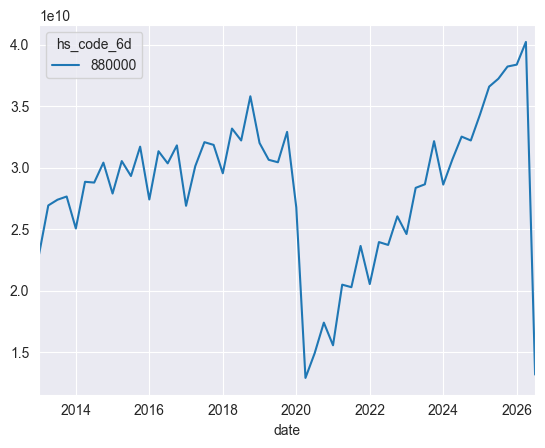

In [14]:
trade_pivot_df[['880000']].plot()

In [15]:
yoy_trade_growth[['841112']].tail(8)

hs_code_6d,841112
date,
2024-12-31,81.416354
2025-03-31,25.750799
2025-06-30,118.779000
2025-09-30,48.668200
2025-12-31,16.435559
2026-03-31,20.099922
2026-06-30,0.502814
2026-09-30,-62.242551
